# Laboratorio 9: Proyecto Final: Agenda Medios

Como hemos visto a lo largo de los laboratorios, extraer datos no es una meta por sí misma, sino el punto de partida del Análisis Crítico. Hoy aplicaremos este concepto sobre la principal noticia del día.

En el Lab 004 generamos un extracto directo de la portada del diario nacional La Nación (`lanacion_portada.json`). En la presente actividad demostraremos las redes tangibles en las que se enmarca la realidad política e informativa de nuestra sociedad actual; es decir, **analizaremos la Agenda Setting y los focos de atención del medio periodístico**.

Al finalizar este cuaderno de ejercicios, empaquetaremos estos hallazgos analíticos utilizando lo aprendido en el Lab 000: diseñaremos un *Dashboard* Interactivo con la librería **Gradio**.

## Consigna 1: Carga y Exploración del Corpus

A partir del archivo JSON suministrado (`lanacion_portada.json`), lea el contenido empleando la librería principal de manejo estadístico `pandas`. Inspeccione el encuadre estructural (forma y primeros 5 renglones) a fines de asegurar la fidelidad del traspaso de registros.

In [1]:
import json
import pandas as pd

with open("lanacion_portada.json", encoding="utf-8") as f:
    datos = json.load(f)

df = pd.DataFrame(datos)
print(f"Forma del DataFrame: {df.shape}")
df.head()

Forma del DataFrame: (143, 2)


,seccion,titulo
0,General,Análisis. Un ladrillo flojo sacude la arquitec...
1,General,Tensión con la prensa. El Gobierno prohíbe el ...
2,General,Viaje familiar. La Justicia confirmó que Adorn...
3,General,"Máxima tensión. Con un video, Irán exhibe su c..."
4,General,"""Una recesión rarísima"". La frase de Galperin ..."


## Consigna 2: Visualización Temática de Agenda Periodística

Con nuestra tabla constituida, buscaremos responder una pregunta clave de investigación: **¿Qué temática decidió priorizar jerárquicamente la línea editorial en su portada de hoy?**

Filtre valores nulos y estructure una representación categórica (ejemplo `sns.barplot()` con orientación horizontal) de modo que exponga de manera irrefutable qué secciones ostentan la mayor cantidad de aparatos editoriales (notas emitidas). Agregue un título informativo y recuerde aplicar principios rigurosos de Data-Ink Ratio.

C:\Users\54116\AppData\Local\Temp\ipykernel_32484\600553962.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo, y="seccion", x="cantidad", orient="h", palette="Blues_r", ax=ax)


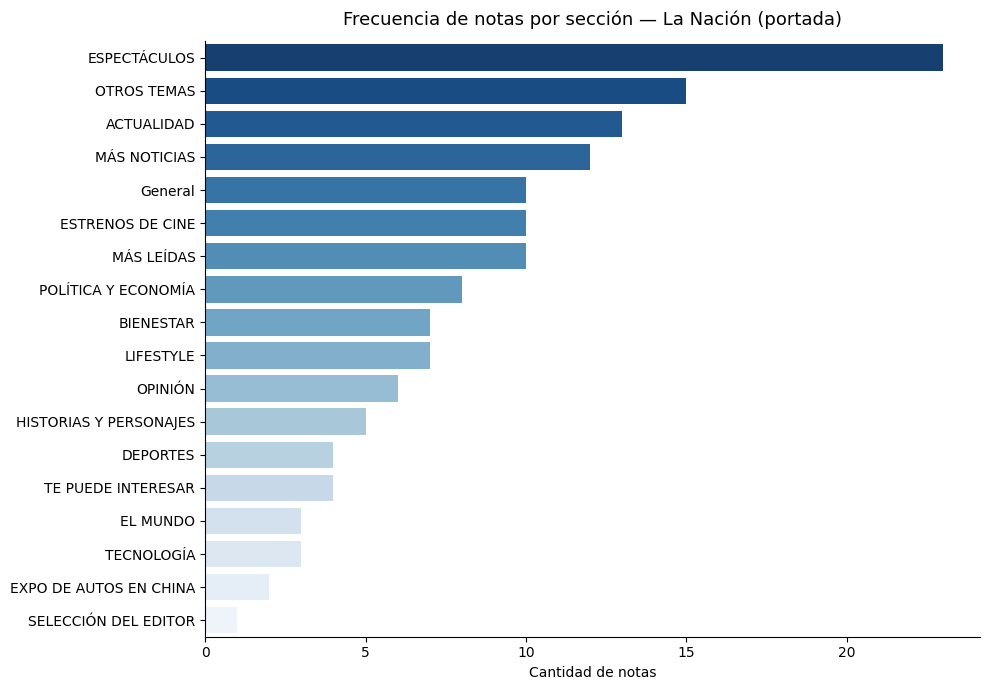

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo = df["seccion"].dropna().value_counts().reset_index()
conteo.columns = ["seccion", "cantidad"]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=conteo, y="seccion", x="cantidad", orient="h", palette="Blues_r", ax=ax)
ax.set_title("Frecuencia de notas por sección — La Nación (portada)", fontsize=13, pad=12)
ax.set_xlabel("Cantidad de notas")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Consigna 3: Pesos del Lenguaje (Redes Léxicas)

Con la temática confirmada, deconstruiremos semánticamente esos focos de atención aislando el lenguaje que envuelve al contenido principal. Emplearemos el *Lollipop Chart* abordado en metodologías previas para proyectar las 15 palabras clave con mayor iteración masiva a lo largo de *toda la portada* titular.

Identifique las iteraciones que se formulan más allá de conectores y artículos nulos (*stop words*). ¿Cuál de estos nodos terminológicos monopoliza el marco informativo de la presente fecha?

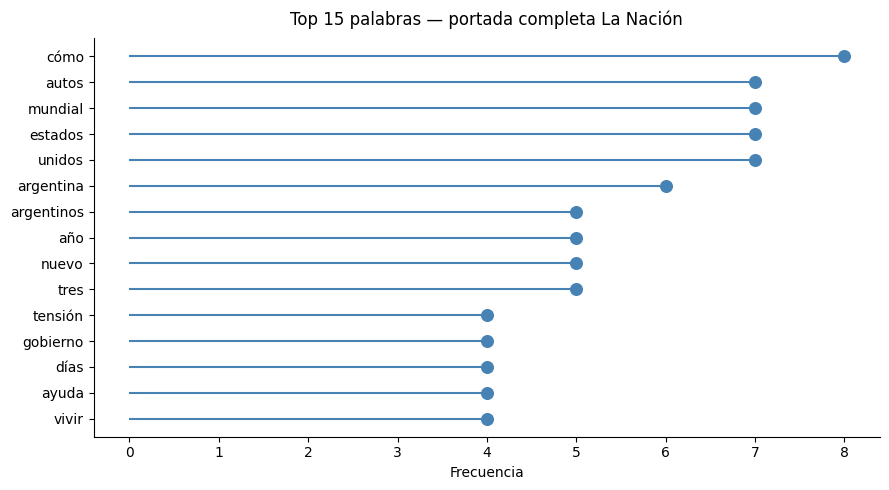

In [5]:
import re
from collections import Counter

stopwords_es = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para",
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este",
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta",
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni",
    "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", "antes", "algunos",
    "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes",
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros",
    "mis", "tú", "te", "ti", "tu", "tus", "ellas", "nosotras", "fui", "fuiste", "fue", "fuimos",
    "fueron", "era", "eras", "eran", "sido", "siendo", "soy", "eres", "es", "somos", "son",
    "tengo", "tienes", "tiene", "tenemos", "tienen", "tenía", "tenían", "tuve", "tuvo", "hubo",
    "hay", "ser", "estar", "haber", "tener", "hacer", "decir", "ver", "dar", "saber", "querer",
    "llegar", "pasar", "deber", "poner", "parecer", "quedar", "creer", "hablar", "llevar",
    "mi", "mis", "tu", "tus", "su", "sus",
}


def top_palabras(titulos, n=15):
    texto = " ".join(titulos).lower()
    tokens = re.findall(r"\b[a-záéíóúüñ]{3,}\b", texto)
    freq = Counter(t for t in tokens if t not in stopwords_es)
    return freq.most_common(n)


def grafico_lollipop(palabras_freq, titulo="Top palabras"):
    if not palabras_freq:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center")
        ax.axis("off")
        return fig
    palabras = [p for p, _ in reversed(palabras_freq)]
    frecuencias = [f for _, f in reversed(palabras_freq)]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hlines(y=range(len(palabras)), xmin=0, xmax=frecuencias, color="steelblue", linewidth=1.5)
    ax.scatter(frecuencias, range(len(palabras)), color="steelblue", s=70, zorder=3)
    ax.set_yticks(range(len(palabras)))
    ax.set_yticklabels(palabras)
    ax.set_title(titulo, fontsize=12, pad=10)
    ax.set_xlabel("Frecuencia")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    return fig


# Aplicar sobre el corpus completo
top15_global = top_palabras(df["titulo"].dropna().tolist())
fig_global = grafico_lollipop(top15_global, "Top 15 palabras — portada completa La Nación")
plt.show()


## Consigna Final: Dashboard Dinámico de Sentido con Gradio

Integrar y escalar el diseño. Acaba de confirmar metodológicamente la agenda principal y el vocabulario dominador del periódico entero. Ahora envuélvalo funcionalmente convirtiéndolo en una Interface Web que logre desglosar el contenido respondiendo filtros particulares del investigador.

Deberá programar una Interfaz Gradio (`gr.Interface` o `gr.Blocks`) que exponga un **Desplegable (Dropdown)** poblado con las Secciones halladas (`Política`, `Economía`, `Sociedad`, etc.). 
La selección del usuario invocará una función que:
1. Cribe al DataFrame dejando solamente artículos pertenecientes a dicha sección.
2. Genere dos *outputs* (Salidas): 
    * Una tabla (`gr.Dataframe` o texto) enumerando puros títulos resultantes de esa sección selecta.
    * El gráfico del analizador de pesos (`Lollipop de frecuencias`) re-computado exclusivamente sobre el vocabulario de la sección elegida.

> Al correr la Interfaz, notará instantáneamente cómo el eje material y discursivo muta violentamente de polaridad con el simple acto interactivo de mover de 'Política' a 'Cultura'.

In [6]:
import gradio as gr

secciones = sorted(df["seccion"].dropna().unique().tolist())


def analizar_seccion(seccion):
    subset = df[df["seccion"] == seccion][["titulo"]].reset_index(drop=True)
    titulos = subset["titulo"].tolist()
    top15 = top_palabras(titulos)
    fig = grafico_lollipop(top15, f"Top palabras — {seccion}")
    return subset, fig


iface = gr.Interface(
    fn=analizar_seccion,
    inputs=gr.Dropdown(choices=secciones, value=secciones[0], label="Sección"),
    outputs=[
        gr.Dataframe(label="Títulos de la sección", wrap=True),
        gr.Plot(label="Redes léxicas (Top 15 palabras)"),
    ],
    title="Dashboard: Agenda Setting — La Nación",
    description="Seleccioná una sección para ver sus títulos y el vocabulario dominante.",
    flagging_mode="never",
)

iface.launch(inline=True, show_error=True)


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
